# EM Clustering in 2D – Gaussian Mixture Models

Author: Mikołaj Jędruch

##Creating Dataset

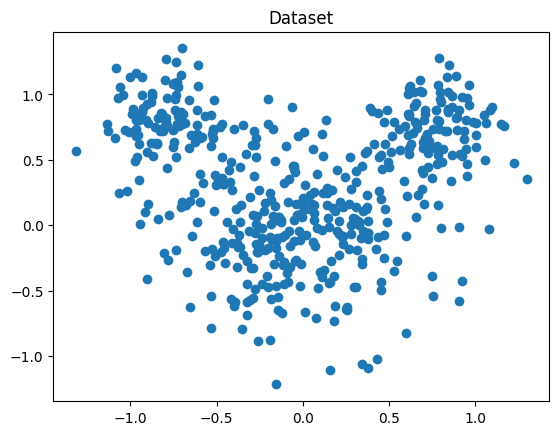

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# SECTION 1: Generate the "mouse" dataset
# ----------------------------------------------------------------------
np.random.seed(0)  # for reproducibility

# 1) 300 points from N([0, 0], [[0.16, 0],[0, 0.16]])
mean1 = np.array([0.0, 0.0])
cov1 = np.array([[0.16, 0.0],
                 [0.0,  0.16]])
data1 = np.random.multivariate_normal(mean1, cov1, 300)

# 2) 100 points from N([0.8, 0.8], [[0.04, 0],[0, 0.04]])
mean2 = np.array([0.8, 0.8])
cov2 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data2 = np.random.multivariate_normal(mean2, cov2, 100)

# 3) 100 points from N([-0.8, 0.8], [[0.04, 0],[0, 0.04]])
mean3 = np.array([-0.8, 0.8])
cov3 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data3 = np.random.multivariate_normal(mean3, cov3, 100)

# Combine all data
X = np.vstack([data1, data2, data3])
N, d = X.shape  # should be (500, 2)

#Plot dataset
plt.scatter(X[:,0], X[:,1])
plt.title("Dataset")
plt.show()

#Fit GMM

In [13]:
from sklearn.mixture import GaussianMixture
from matplotlib.colors import Normalize

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)

labels = gmm.predict(X)

##Cluster visualization

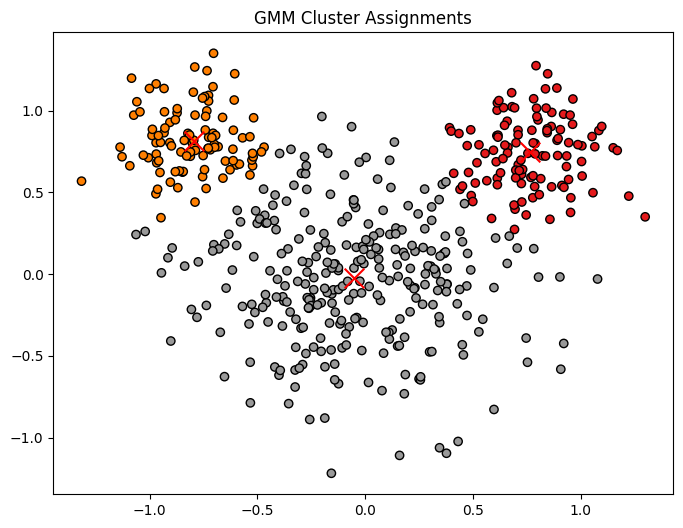

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='Set1', edgecolor='k')
plt.scatter(gmm.means_[:,0], gmm.means_[:,1], c='red', marker='x', s=200)

plt.title("GMM Cluster Assignments")
plt.show()

#Decision boundary

In [15]:
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-2, X[:,0].max()+2, 300),
    np.linspace(X[:,1].min()-2, X[:,1].max()+2, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
probs = gmm.predict_proba(grid)
Z = np.argmax(probs, axis=1)
Z = Z.reshape(xx.shape)

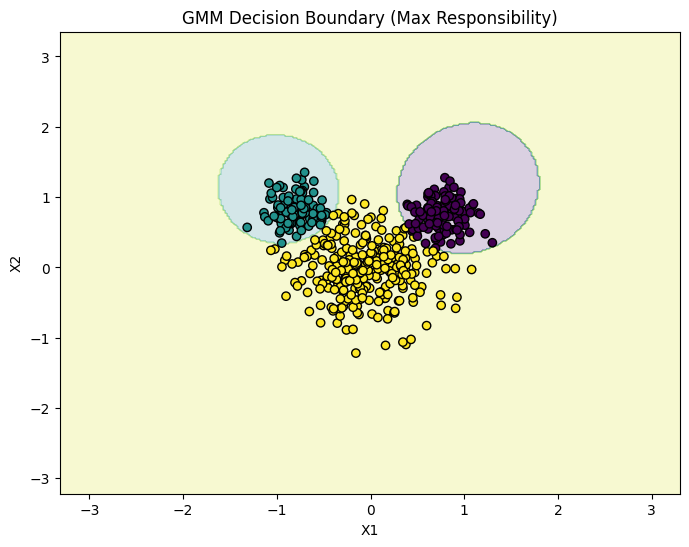

In [16]:
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=labels, edgecolor='k')

plt.title("GMM Decision Boundary (Max Responsibility)")
plt.xlabel("X1")
plt.ylabel("X2")

plt.show()

## Decision Boundary Interpretation

Each region in the plot corresponds to the cluster with the highest posterior probability:

$$
\arg\max_k P(z = k \mid x)
$$

Unlike k-means, which produces linear boundaries, GMM results in non-linear decision boundaries.

### Observed Irregularities

We can see that some clusters contain only small portions of space, while another bigger cluster covers most of it.
This occurs because GMM assigns probability density, not distance. Components with larger covariance decay more slowly and dominate smaller ones after some distance. Thats why points closer to other clusters will fall into another bigger cluster. In our case e.g. points in the upper left corner are closer to left ear, but are assigned to main "body" cluster.

Decision boundaries can be unintuitive and differ significantly from geometric intuition.

#Metrics to choose K

##Silhouette score

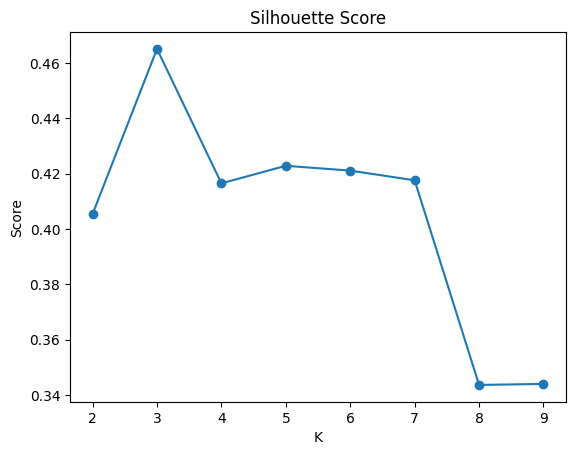

In [17]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 10):
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    labels = gmm.fit_predict(X)
    scores.append(silhouette_score(X,labels))

plt.plot(range(2,10), scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

As we can see, silhouette score achieves the best result for 3 clusters. It is a decent metric, but not the best for GMM.

##Inertia

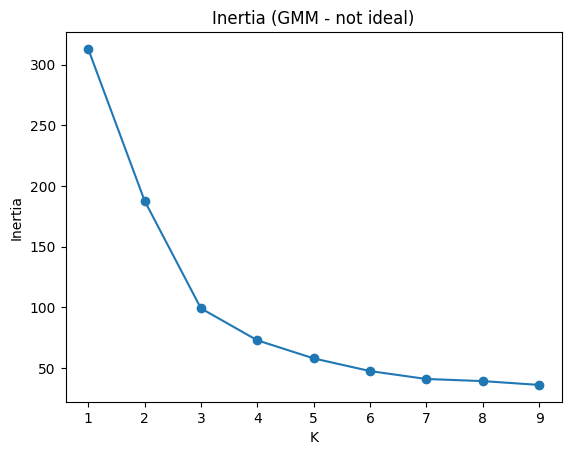

In [18]:
inertias = []
K_range = range(1, 10)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X)

    labels = gmm.predict(X)
    inertia = np.sum((X - gmm.means_[labels])**2)

    inertias.append(inertia)

plt.plot(K_range, inertias, marker='o')
plt.title("Inertia (GMM - not ideal)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

Inertia can be computed for GMM, but it is not accurate. Inertia assumes that the clusters are spherical. Which in the case of GMM is not true. There is no visible "knee" on the graph.

##BIC

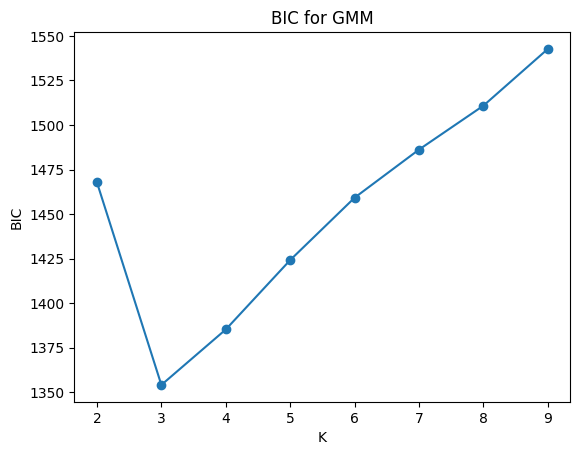

In [19]:
bic = []

for k in range(2, 10):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X)
    bic.append(gmm.bic(X))

plt.plot(range(2,10), bic, marker='o')
plt.title("BIC for GMM")
plt.xlabel("K")
plt.ylabel("BIC")
plt.show()

###What is BIC?
$$
\mathrm{BIC} = -2 \log \big( \hat{L} \big) + p \log n
$$
- $L$ is the likelihood of the model (how well it fits the data)
- $p$ is the number of parameters in the model
- $n$ is the number of data points

The first term rewards good fit,
while the second term penalizes model complexity.
The best number K gives the smallest BIC score. In our case 3 is clearly the best number of clusters

## Finding K Conclusion
In general to find the best number of clusters I would plot the silhouette and BIC. From my research BIC is one of the best methods for the GMM model so I would focus on this metric